#### Approve or Reject

让人类批准一次 API 调用、一次数据库更改或任何其他重要决策。

In [1]:
from typing import Literal, TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


class ApprovalState(TypedDict):
    action_details: str
    status: Literal["pending", "approved", "rejected"] | None


def approval_node(state: ApprovalState) -> Command[Literal["proceed", "cancel"]]:
    # Expose details so the caller can render them in a UI
    decision = interrupt({
        "question": "Approve this action?",
        "details": state["action_details"],
    })

    # Route to the appropriate node after resume
    return Command(goto="proceed" if decision else "cancel")


def proceed_node(state: ApprovalState):
    return {"status": "approved"}


def cancel_node(state: ApprovalState):
    return {"status": "rejected"}


builder = StateGraph(ApprovalState)
builder.add_node("approval", approval_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)
builder.add_edge(START, "approval")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)

# Use a more durable checkpointer in production
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [2]:
config = {"configurable": {"thread_id": "approval-123"}}
initial = graph.invoke(
    {"action_details": "Transfer $500", "status": "pending"},
    config=config, # type: ignore
)
initial

{'action_details': 'Transfer $500',
 'status': 'pending',
 '__interrupt__': [Interrupt(value={'question': 'Approve this action?', 'details': 'Transfer $500'}, id='0b4d4a43de249accab4683911e6987f3')]}

In [3]:
# Resume with the decision; True routes to proceed, False to cancel
resumed = graph.invoke(Command(resume=True), config=config) # type: ignore
resumed

{'action_details': 'Transfer $500', 'status': 'approved'}

#### Validate Human Input

In [4]:
class FormState(TypedDict):
    age: int | None


def get_age_node(state: FormState):
    prompt = "What is your age?"

    while True:
        answer = interrupt(prompt)  # payload surfaces in result["__interrupt__"]

        if isinstance(answer, int) and answer > 0:
            return {"age": answer}

        prompt = f"'{answer}' is not a valid age. Please enter a positive number."


builder = StateGraph(FormState)
builder.add_node("collect_age", get_age_node)
builder.add_edge(START, "collect_age")
builder.add_edge("collect_age", END)

graph = builder.compile(checkpointer=InMemorySaver())

In [5]:
config = {"configurable": {"thread_id": "form-1"}}
first = graph.invoke({"age": None}, config=config) # type: ignore
first

{'age': None,
 '__interrupt__': [Interrupt(value='What is your age?', id='f79a07b505ce8d7fc2ca244ad1088ff7')]}

In [6]:
# Provide invalid data; the node re-prompts
retry = graph.invoke(Command(resume="thirty"), config=config) # type: ignore
retry

{'age': None,
 '__interrupt__': [Interrupt(value="'thirty' is not a valid age. Please enter a positive number.", id='f79a07b505ce8d7fc2ca244ad1088ff7')]}

In [7]:
# Provide valid data; loop exits and state updates
final = graph.invoke(Command(resume=30), config=config) # type: ignore
final

{'age': 30}

#### Review and Edit State

In [8]:
class ReviewState(TypedDict):
    generated_text: str


def review_node(state: ReviewState):
    # Ask a reviewer to edit the generated content
    updated = interrupt({
        "instruction": "Review and edit this content",
        "content": state["generated_text"],
    })
    return {"generated_text": updated}


builder = StateGraph(ReviewState)
builder.add_node("review", review_node)
builder.add_edge(START, "review")
builder.add_edge("review", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [9]:
config = {"configurable": {"thread_id": "review-42"}}
initial = graph.invoke({"generated_text": "Initial draft"}, config=config) # type: ignore
initial

{'generated_text': 'Initial draft',
 '__interrupt__': [Interrupt(value={'instruction': 'Review and edit this content', 'content': 'Initial draft'}, id='29e0797a0915d08bee9807c1f7bbf262')]}

In [10]:
# Resume with the edited text from the reviewer
final_state = graph.invoke(Command(resume="Improved draft after review"), config=config) # type: ignore
final_state

{'generated_text': 'Improved draft after review'}

#### Handling multiple interrupts

In [11]:
from typing import Annotated
import operator


class State(TypedDict):
    vals: Annotated[list[str], operator.add]


def node_a(state):
    answer = interrupt("question_a")
    return {"vals": [f"a:{answer}"]}


def node_b(state):
    answer = interrupt("question_b")
    return {"vals": [f"b:{answer}"]}


graph = (
    StateGraph(State)
    .add_node("a", node_a)
    .add_node("b", node_b)
    .add_edge(START, "a")
    .add_edge(START, "b")
    .add_edge("a", END)
    .add_edge("b", END)
    .compile(checkpointer=InMemorySaver())
)

In [12]:
config = {"configurable": {"thread_id": "1"}}

# Step 1: invoke - both parallel nodes hit interrupt() and pause
interrupted_result = graph.invoke({"vals": []}, config) # type: ignore
interrupted_result

{'vals': [],
 '__interrupt__': [Interrupt(value='question_a', id='b2089c5fe90d43d00739d5f469e703b9'),
  Interrupt(value='question_b', id='6199736c889a2d0c61b1be410299673a')]}

将每个中断 ID 映射到其恢复值，确保在运行时每个响应都与正确的中断配对。

In [13]:
# Step 2: resume all pending interrupts at once
resume_map = {
    i.id: f"answer for {i.value}"
    for i in interrupted_result["__interrupt__"]
}
result = graph.invoke(Command(resume=resume_map), config) # type: ignore
result

{'vals': ['a:answer for question_a', 'b:answer for question_b']}

#### Interrupts in tools

In [14]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model


class AgentState(TypedDict):
    messages: list[dict]


@tool
def send_email(to: str, subject: str, body: str):
    """Send an email to a recipient."""

    # Pause before sending; payload surfaces in result["__interrupt__"]
    response = interrupt({
        "action": "send_email",
        "to": to,
        "subject": subject,
        "body": body,
        "message": "Approve sending this email?",
    })

    if response.get("action") == "approve":
        final_to = response.get("to", to)
        final_subject = response.get("subject", subject)
        final_body = response.get("body", body)

        # Actually send the email (your implementation here)
        print(f"[send_email] to={final_to} subject={final_subject} body={final_body}")
        return f"Email sent to {final_to}"

    return "Email cancelled by user"

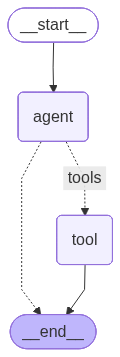

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from agent_lab.model_hub import LLM_FAST

model = init_chat_model(**LLM_FAST).bind_tools([send_email])

def agent_node(state: AgentState):
    # LLM may decide to call the tool; interrupt pauses before sending
    result = model.invoke(state["messages"])
    return {"messages": state["messages"] + [result]}

builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tool", ToolNode([send_email]))
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tool", END: END},
)
builder.add_edge("tool", END)

graph = builder.compile(checkpointer=InMemorySaver())

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
from langchain.messages import HumanMessage

prompt = '''
Send an email to alice@example.com about the meeting.
(Functional testing is in progress. Please directly call the relevant tools, and you can fill in the parameters arbitrarily.)
'''
config = {"configurable": {"thread_id": "email-workflow"}}
initial = graph.invoke({'messages': [HumanMessage(prompt)]}, config=config) # type: ignore
print(initial["__interrupt__"])

[Interrupt(value={'action': 'send_email', 'to': 'alice@example.com', 'subject': 'Meeting Reminder', 'body': 'Hi Alice,\n\nJust a quick reminder about our upcoming meeting this Friday at 2:00 PM. Please let me know if you have any questions.\n\nBest regards,\nJohn', 'message': 'Approve sending this email?'}, id='61900d7a50183e1f3f5fbb76f65d414a')]


In [17]:
# Resume with approval and optionally edited arguments
resumed = graph.invoke(
    Command(resume={"action": "approve", "subject": "Updated subject"}),
    config=config, # type: ignore
)
resumed["messages"][-1].pretty_print()

[send_email] to=alice@example.com subject=Updated subject body=Hi Alice,

Just a quick reminder about our upcoming meeting this Friday at 2:00 PM. Please let me know if you have any questions.

Best regards,
John
================================= Tool Message =================================
Name: send_email

Email sent to alice@example.com
